In [1]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

# Search for root via .git
root = next(p for p in [Path().resolve(), *Path().resolve().parents] if (p / '.git').exists())

sys.path.insert(0, str(root / 'code'))
from sde_routines import *

sys.path.insert(0, str(root / 'data'))
from data_loader import *
from data_generator import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Get the data

In [2]:
Data = load_quijote(fact=2)
#Data = load_turbulence_2D(fact=2)[:400].to(device)
#Data = generate_gaussian((64,64), 100, alpha=2)

x1 = normalize(Data[:100]).to(device)

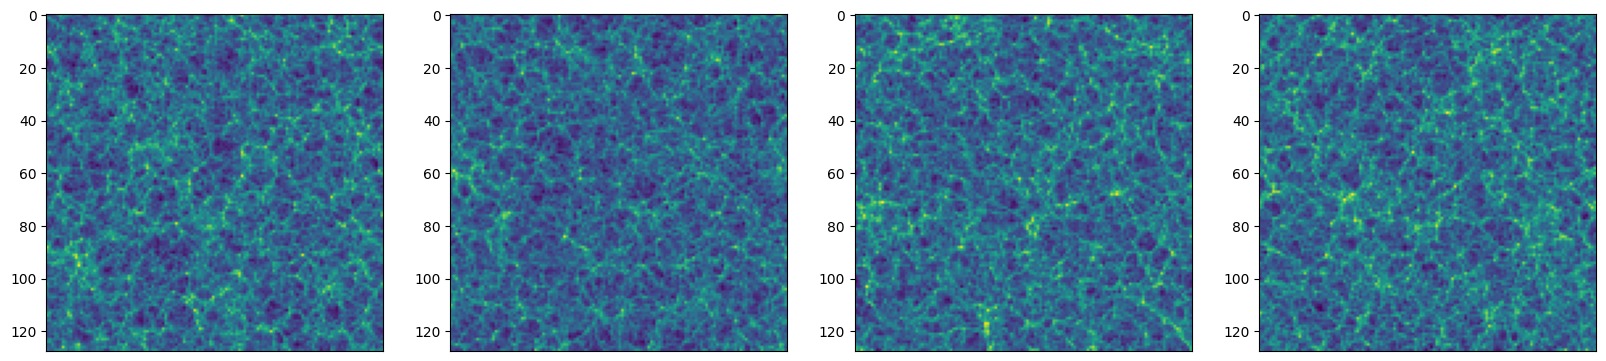

In [3]:
plot_image_row(x1, 4)

### Choose the model

In [4]:
# model parameters
n1, channels, M, _ = x1.shape
J = 5
Q = 1
L = 4

# choose terms in the model
terms = ['Scattering_Second_Order', 'Scattering_First_Order', 'Scattering_Third_Order_Real']#, 'Scattering_Fourth_Order_Real']

# filters
filters = return_Filters(M, J, Q, L=L, device=device)

In [5]:
potentials = get_2d_potentials(terms, J, L, filters, parallel=False)

### Solve the SDE

In [6]:
# SDE parameters
interpolant = 'Cos'
nt          = 1000
t           = 1-(1-torch.linspace(0, 1, nt + 1))**1
sigma       = 1

nb_workers      = x1.shape[0] # number of particles
nb_interpolants = x1.shape[0] # number of I_t (not necessarily the dataset size, since several noise paths could be considered per data sample)

batch_size = 20

Solver = SDE(x1, nb_workers, nb_interpolants, t, sigma, potentials, batch_size, device=device, regularization=(0,0,0), interpolant=interpolant, x_0=None, x_k=None)

Signal detected as 2D: (B, C, M, N) = (20, 1, 128, 128).
The model has 303 potentials.


In [7]:
xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound = Solver()

1000it [11:17,  1.48it/s]


In [8]:
config = 'quijote_128_J_5_sigma_1'

save_results(xt, theta_t, dH_t_bound, t, root, config)

## Analyze the result

Looking at the samples and moment matching along the dynamics:

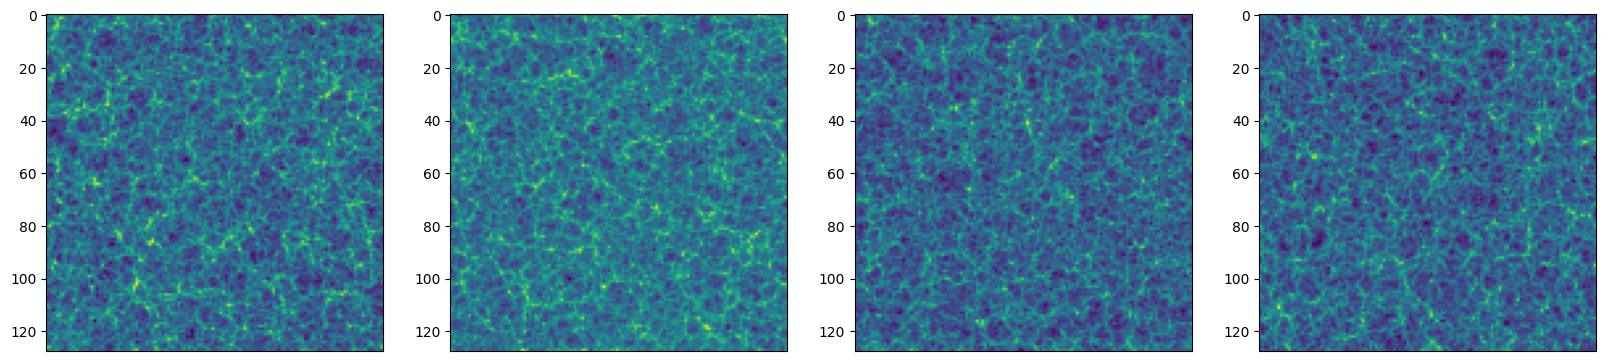

In [9]:
# Samples
plot_image_row(xt, 4)

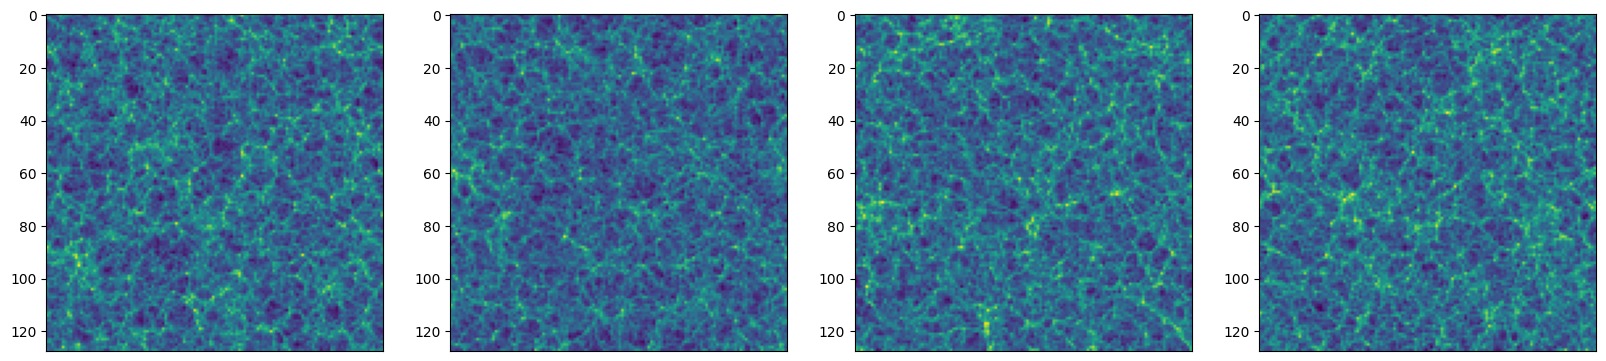

In [10]:
# Originals
plot_image_row(x1, 4)

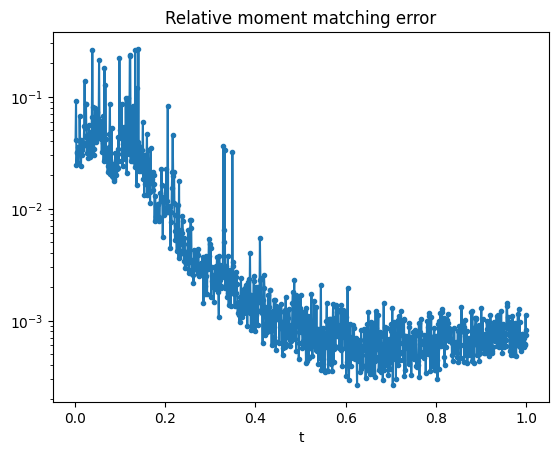

In [11]:
# Check (non negligible) moments matching

threshold = 1e-6 # threshold above which should be considered

plot_moment_matching(barphi_e, barphi_p, t, threshold)

Entropy bound evolution and comparison with the equivalent gaussian entropy (covariance directly estimated from the original data):

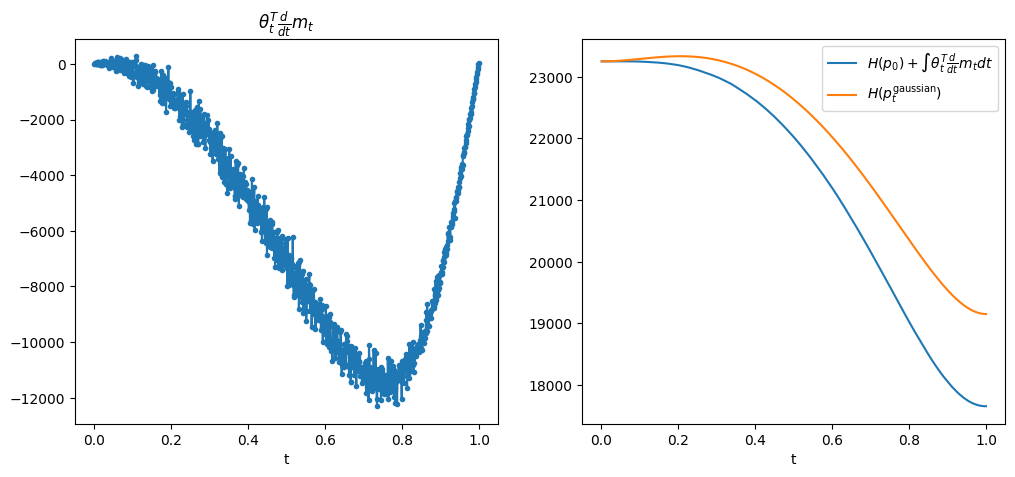

In [12]:
d = x1.shape[-2]*x1.shape[-1]
H_p_0 = (np.log(2*np.pi)+1)*d/2

H_t_bound = dH_t_bound.cumsum(0).cpu()/nt + H_p_0
H_t_gaussian = compute_gaussian_entropy(x1, interpolant, t)

plot_entropy_bound_evolution(dH_t_bound, H_t_bound, H_t_gaussian, t)

Compare the entropy bound $H^\sigma_*$ with the gaussian estimation of the entropy at time $t=1$:

In [13]:
print('Entropy bound:', H_t_bound[-1], '.')
print('Gaussian estimation', H_t_gaussian[-1], '.')

Entropy bound: tensor(17658.1914) .
Gaussian estimation tensor(19152.5938) .
